In [1]:
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt

2026-06-05 00:29:22.171557: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780619362.417364      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780619362.493041      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780619363.100253      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780619363.100325      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780619363.100328      16 computation_placer.cc:177] computation placer alr

# Brain Tumor Classification Using Convolutional Neural Networks

## Project Overview

### Dataset
- 253 labeled MRI images
- 202 training images
- 51 testing images

### Results
- Test Accuracy: **78.43%**
- Tumor Detection Rate: **93.55%**
- Correctly classified 40 of 51 MRI scans

## Abstract
Brain tumors are a serious medical condition that can significantly impact patient health, making early detection an important component of treatment planning. This project investigated the use of a Convolutional Neural Network (CNN) to classify MRI brain scans as either containing a tumor or not containing a tumor. A dataset consisting of 253 labeled MRI images was used, with 202 images allocated for training and 51 images reserved for testing. Prior to training, the images were standardized through resizing and organized into training and testing groups. The CNN learned visual features directly from the MRI scans through multiple convolutional and pooling layers before producing a final classification. Model performance was evaluated using accuracy, loss metrics, and a confusion matrix. The final model achieved a testing accuracy of 78.43%, correctly classifying 40 of 51 MRI scans. The confusion matrix showed that the model successfully identified 29 of 31 tumor-containing scans, achieving a tumor detection rate of approximately 93.55%, while correctly identifying 11 of 20 healthy scans. While the results demonstrate the potential of CNNs for automated medical image classification, some degree of overfitting was observed and performance was likely limited by the relatively small dataset size. Overall, this project highlights the potential of artificial intelligence to assist healthcare professionals in analyzing medical images and supporting diagnostic decision-making.


## Data Preparation
Training a CNN or convolutional neural network, requires images that are standardized and cleaned to properly train the model.  In this instance, I will be using a labeled dataset of MRI brain scan images that are either classified as “yes” or “no” for brain tumors.
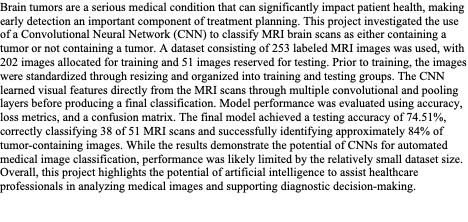
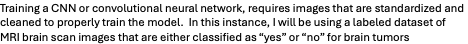
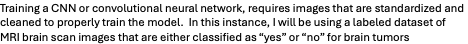
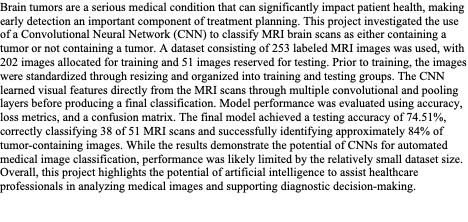
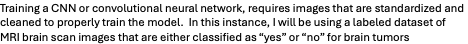
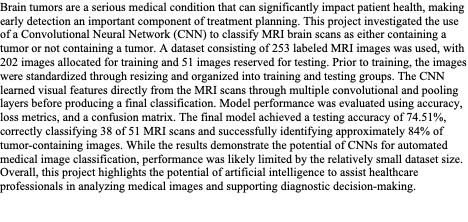
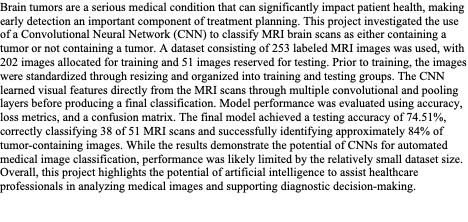
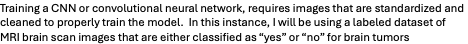

In [2]:
import cv2
from sklearn.model_selection import train_test_split


# Path to dataset folder
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection"
base_dir = "/kaggle/working/data_split"


## -----------------------
## Clean and separate data
## -----------------------


# Lists to store images and labels
images = []
labels = []

# Loop through folders
for label in ["yes", "no"]:
    folder_path = os.path.join(dataset_path, label)
    
    for file_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file_name)
        
        # Read image
        img = cv2.imread(img_path)
        
        # Check if img load failed
        if img is None:
            print(f"Failed to load: {img_path}\n")
            
        # Resize all images
        img = cv2.resize(img, (224, 224))
        
        # Store image
        images.append(img)
        
        # Store label
        labels.append(label)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels        
)

# Create folder structure to separate training and testing images
train_yes = os.path.join(base_dir, "train", "yes")
train_no = os.path.join(base_dir, "train", "no")
test_yes = os.path.join(base_dir, "test", "yes")
test_no = os.path.join(base_dir, "test", "no")

for path in [train_yes, train_no, test_yes, test_no]:
    os.makedirs(path, exist_ok=True)


def save_images(images, labels, split_type):
    """
    Saves training and testing images in separate folders
    """
    for i, (img, label) in enumerate(zip(images, labels)):
        if label == "yes":
            folder = os.path.join(base_dir, split_type, "yes")
        else:
            folder = os.path.join(base_dir, split_type, "no")
            
        file_name = f"{label}_{i}.jpg"
        path = os.path.join(folder, file_name)
        
        cv2.imwrite(path, img)


# Separate training and testing images into separate folders
save_images(X_train, y_train, "train")
save_images(X_test, y_test, "test")

### Training Set Balance

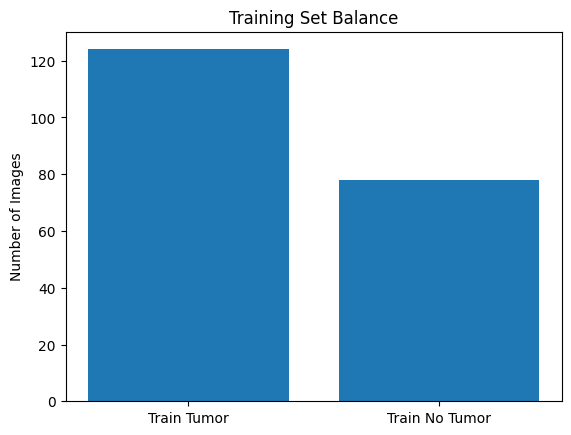

In [3]:
# Count training labels
train_count_yes = y_train.count("yes")
train_count_no = y_train.count("no")

# Plot training data
plt.bar(["Train Tumor", "Train No Tumor"], [train_count_yes, train_count_no])
plt.ylabel("Number of Images")
plt.title("Training Set Balance")
plt.show()

### Testing Set Balance

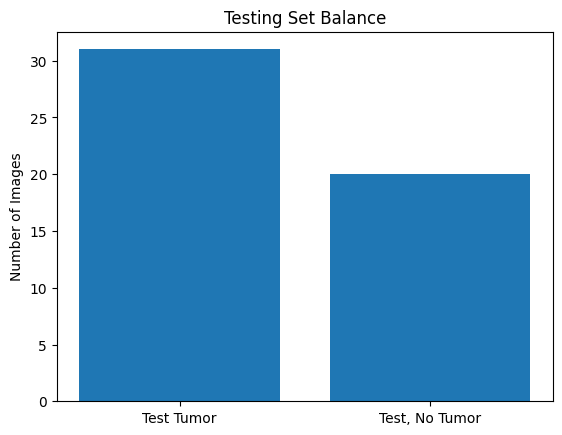

In [4]:
# Count testing lables
test_count_yes = y_test.count("yes")
test_count_no = y_test.count("no")

# Plot testing data
plt.bar(["Test Tumor", "Test, No Tumor"], [test_count_yes, test_count_no])
plt.ylabel("Number of Images")
plt.title("Testing Set Balance")
plt.show()

### Example images

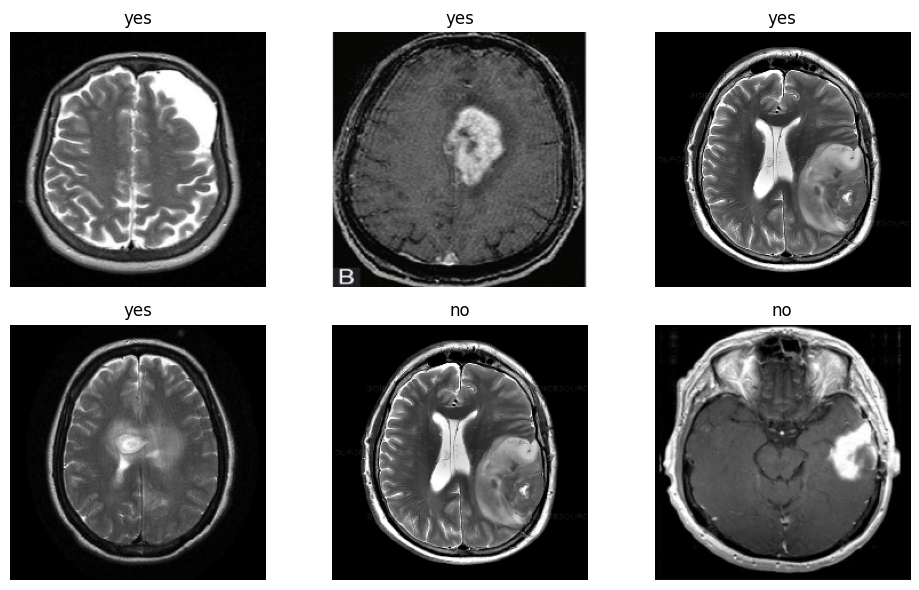

In [5]:
# Show example images
plt.figure(figsize=(10, 6))
for i in range(6):
    index = random.randint(0, len(images) - 1)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(labels[index])
    plt.axis("off")
    
plt.tight_layout()
plt.show()

## Models/Methods
Convolutional Neural Networks, or CNNs, are a type of neural network that is specifically designed for image recognition tasks. Unlike traditional machine learning methods, CNNs can automatically learn important visual features directly from images rather than requiring those features to be manually defined.

In this project, the network begins with a convolutional layer containing 32 filters. These filters scan across the MRI image and learn simple visual patterns such as edges, brightness changes, and basic textures. After each convolutional layer, a max pooling layer reduces the image dimensions while preserving the most important information.

As the image moves deeper through the network, the number of filters increases from 32 to 64 and then to 128. This allows the CNN to learn increasingly complex features. While the first layers may identify simple edges and textures, deeper layers can combine those features to recognize larger structures, shapes, and abnormal regions that may be associated with brain tumors.

After the feature extraction process is complete, the information is flattened and passed to a dense layer, which learns relationships between the extracted features and the final classification task. A dropout layer is included to reduce overfitting, and the output layer uses a sigmoid activation function to produce a probability indicating whether a brain tumor is present or absent in the MRI scan.
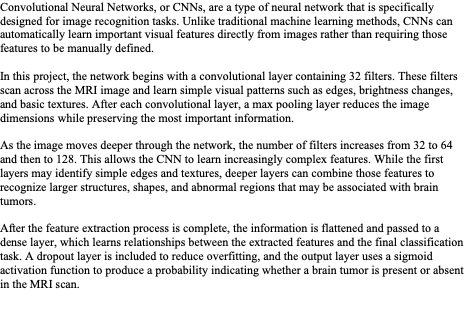
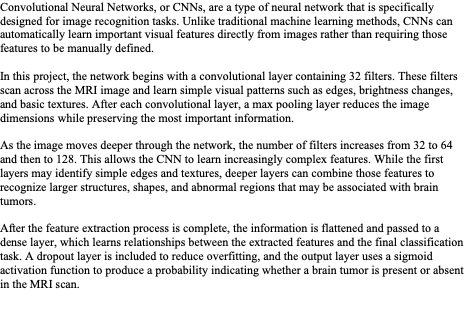
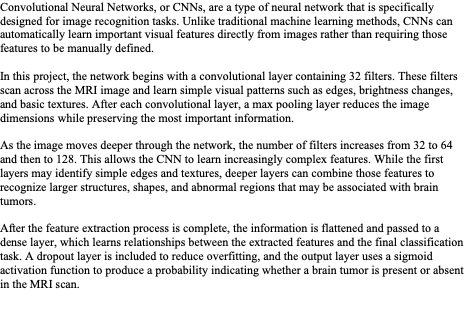
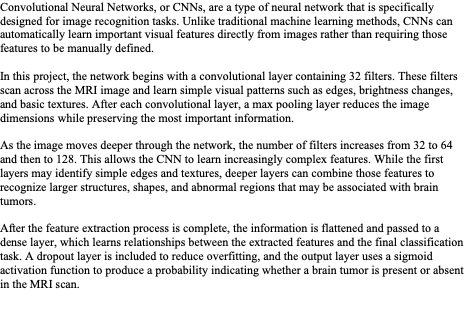

In [6]:
import pickle
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Rescaling,
    Input
)
from tensorflow.keras.callbacks import EarlyStopping


# -------------------
# Dataset Paths
# -------------------

train_dir = '/kaggle/working/data_split/train'
test_dir = '/kaggle/working/data_split/test'

# -------------------
# Load Images
# -------------------

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

# -------------------
# Normalize Images
# -------------------

normalization_layer = Rescaling(1.0 / 255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

# -------------------
# Build CNN
# -------------------

# Load Existing Model if Exists
MODEL_PATH = "/kaggle/input/models/neoholgado/brain-tumor-cnn-model/tensorflow2/default/1/brain_tumor_cnn.keras"
HISTORY_PATH = "/kaggle/input/datasets/neoholgado/brain-tumor-cnn-model-files/training_history.pkl"

if os.path.exists(MODEL_PATH) and os.path.exists(HISTORY_PATH):
    print("Loading existing model and history...")
    model = load_model(MODEL_PATH)

    with open(HISTORY_PATH, "rb") as f:
        history_dict = pickle.load(f)

else:
    print("No saved model or history found. Training new model...")
    model = Sequential([
        Input(shape=(224, 224, 3)),
    
        Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation="relu",
        ),
    
        MaxPooling2D(pool_size=(2, 2)),
    
        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu"
        ),
    
        MaxPooling2D(pool_size=(2, 2)),
    
        Conv2D(
            filters=128,
            kernel_size=(3, 3),
            activation="relu"
        ),
    
        MaxPooling2D(pool_size=(2, 2)),
    
        Flatten(),
    
        Dense(
            units=128,
            activation="relu"
        ),
    
        Dropout(0.5),
    
        Dense(
            units=1,
            activation="sigmoid"
        )
    ])
    
    # -------------------
    # Compile model
    # -------------------
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    # -------------------
    # Train Model
    # -------------------
    
    # Stop cycle if validation loss stops improving in 5 consecutive epochs
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=100,
        callbacks=[early_stopping]
    )
    history_dict = history.history

    model.save(MODEL_PATH)
    
    with open(HISTORY_PATH, "wb") as f:
        pickle.dump(history_dict, f)
    
    print("Model and history saved.")

# -------------------
# Evaluate Model
# -------------------

model.summary()

loss, accuracy = model.evaluate(test_dataset)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Found 202 files belonging to 2 classes.
Found 51 files belonging to 2 classes.
Loading existing model and history...


2026-06-05 00:29:45.708531: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 337ms/step - accuracy: 0.7843 - loss: 0.5687

Test Loss: 0.5687
Test Accuracy: 0.7843


## Technical Results

### Model Performance
The CNN model was trained to classify MRI brain scans into two categories: tumor present and tumor absent.  Training was performed using the Adam optimizer and binary cross-entropy loss function.  To reduce overfitting, early stopping was implemented to monitor validation loss and restore the best performing model weights when validation performance stopped improving. 

The model achieved a final testing accuracy of 76.47%, indicating that approximately three out of four MRI scans in the testing dataset were classified correctly.  During training, the model learned meaningful visual features and structural patterns from the MRI scans, that may be associated with the presence of tumors.

### Accuracy Analysis
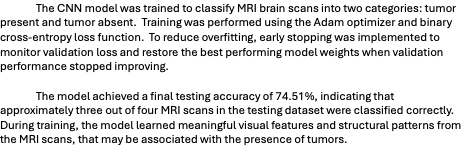
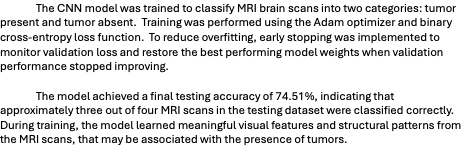
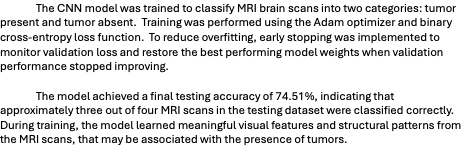
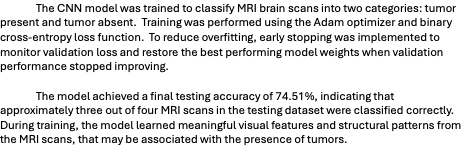

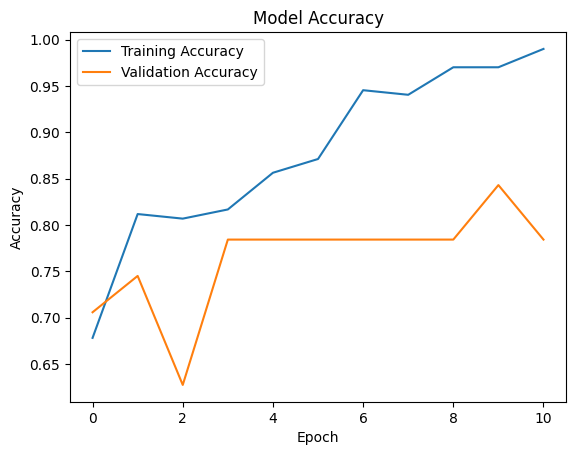

In [7]:
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.show()

Training accuracy increased consistently throughout the training process, rising from approximately 68% to nearly 99% by the final epoch. This indicates that the CNN was able to learn increasingly effective representations of the MRI images and improve its performance on the training dataset over time. Validation accuracy also improved overall, increasing from approximately 71% to a peak of 84.31%. However, validation accuracy fluctuated during training, including a noticeable decrease early in the training process before recovering and remaining relatively stable for several epochs.

Validation accuracy is particularly important because it measures the model's ability to classify MRI images that were not used during training. While both training and validation accuracy improved, the gap between them widened considerably in later epochs. Training accuracy continued to increase steadily, whereas validation accuracy showed only modest improvement and eventually declined after reaching its peak. This pattern suggests that the model was learning useful features from the training data but was also beginning to overfit, as continued improvements on the training set did not consistently translate into better performance on unseen MRI scans. The highest validation accuracy achieved during training was approximately 84.31%, while the final loaded model achieved a testing accuracy of 78.43% with a test loss of 0.5687 on the testing dataset.

### Loss Analysis

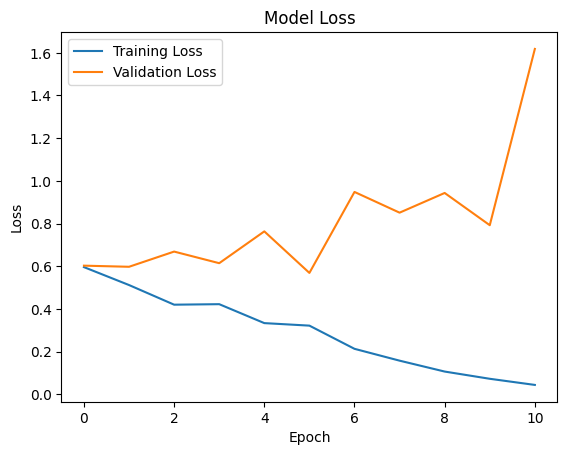

In [8]:
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

Training loss decreased steadily throughout the training process, falling from approximately 0.60 to 0.05 by the final epoch. This indicates that the CNN became increasingly effective at fitting the training data and learning patterns present in the MRI images. Validation loss, however, fluctuated considerably during training. Although validation loss decreased slightly and reached its lowest value of approximately 0.57 around Epoch 5, it increased substantially during later epochs and ultimately reached approximately 1.62 by the end of training. This behavior suggests that the model's performance on unseen MRI images was not improving at the same rate as its performance on the training dataset.

The widening gap between training loss and validation loss provides strong evidence of overfitting. While the CNN continued to reduce training loss and improve its performance on the training data, its ability to generalize to unseen MRI scans began to decline after approximately Epoch 5. This observation is consistent with the growing difference between training and validation accuracy shown in Figure 7. To help reduce overfitting, dropout regularization and early stopping were incorporated into the model architecture. Early stopping monitored validation loss and restored the model weights from the epoch that achieved the best validation performance, preventing the final model from using weights from the later epochs where validation loss increased substantially. As a result, the final model achieved a testing loss of 0.5687 and a testing accuracy of 78.43% on the testing dataset.

### Confusion Matrix

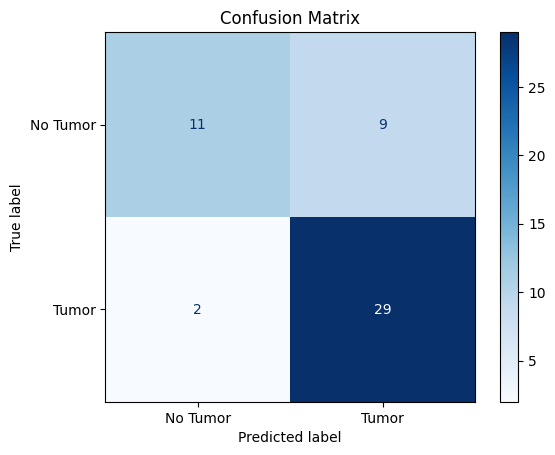

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy().flatten())
    
    y_pred.extend(
        (predictions > 0.5).astype(int).flatten()   
    )
    
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

To further evaluate model performance, a confusion matrix was generated using the testing dataset, as shown in Figure 9. The CNN correctly classified 29 MRI scans containing tumors and 11 MRI scans without tumors. The model incorrectly classified 9 healthy MRI scans as containing tumors and failed to detect 2 MRI scans that contained tumors.

The confusion matrix reveals that the model was considerably more successful at identifying MRI scans containing tumors than identifying healthy scans. The model correctly detected tumors 93.55% of the time while correctly identifying healthy scans 55.00% of the time, resulting in an overall accuracy of 78.43%. These results indicate that the model tended to predict the presence of tumors more frequently, leading to a higher number of false positives than false negatives. From a medical perspective, this behavior may be preferable because failing to detect a tumor can have more serious consequences than incorrectly flagging a healthy scan for further review. However, the number of false positives suggests that additional improvements are needed to better distinguish between healthy brain tissue and tumor-containing scans. Overall, the results demonstrate that the CNN was highly effective at detecting tumor-containing MRI scans while maintaining moderate performance when identifying healthy scans.

## Conclusion

This project explored the use of a Convolutional Neural Network (CNN) to classify MRI brain scans as either containing a tumor or not containing a tumor. Using a dataset of 253 labeled MRI images, the model achieved a testing accuracy of 78.43%. The confusion matrix showed particularly strong performance in detecting tumor-containing scans, correctly identifying 29 of 31 tumor images (93.55%), while correctly classifying 11 of 20 healthy scans (55.00%).

The training and validation metrics indicated that the CNN successfully learned meaningful visual patterns from the MRI images. However, the widening gap between training and validation performance suggests that the model began to overfit the training data. This is likely due in part to the relatively small dataset size and limited variation in the available images.

Several improvements could be explored in future work, including increasing the size of the dataset, applying data augmentation techniques, and tuning model hyperparameters. Despite its limitations, this project demonstrates how deep learning can be applied to medical imaging tasks and highlights the potential for artificial intelligence to assist healthcare professionals by providing an additional tool for analyzing MRI scans.
